In [1]:
import math
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
# config
PARQUET_PATH = Path("df_cleaned_reg.parquet")
TARGET_COL = "bought_in"

INCLUDE_ESTIMATES = False
INCLUDE_ARTIST_NAME = True
RANDOM_STATE = 42

# helpers
def first_existing(candidates: List[str], cols: pd.Index) -> str | None:
    for c in candidates:
        if c in cols:
            return c
    return None

# load data
if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Could not find {PARQUET_PATH.resolve()}")

df = pd.read_parquet(PARQUET_PATH)
print(f"Loaded data with shape: {df.shape}")

if TARGET_COL not in df.columns:
    similar = [c for c in df.columns if "bought" in c.lower() or "sale" in c.lower()]
    raise KeyError(
        f"{TARGET_COL} not found.\n"
        f"Available sale-status-like columns: {similar}"
    )

Loaded data with shape: (6283076, 37)


In [4]:
# identify columns
auction_date_col = first_existing(["auction_start_date"], df.columns)
auction_house_col = first_existing(["auction_house_name"], df.columns)
auction_location_col = first_existing(["auction_location"], df.columns)
currency_col = first_existing(["currency"], df.columns)

artist_name_col = first_existing(["artist_name"], df.columns)
artist_nationality_col = first_existing(["artist_nationality"], df.columns)
artist_gender_col = first_existing(["artist_gender"], df.columns)
artist_birth_col = first_existing(["artist_birth_year", "artist_birth"], df.columns)
artist_death_col = first_existing(["artist_death_year", "artist_death"], df.columns)

medium_col = first_existing(["medium_final"], df.columns)
genre_col = first_existing(["artist_genre"], df.columns)
continent_col = first_existing(["artist_continent"], df.columns)

lot_num_col = first_existing(["lot_num"], df.columns)
width_col = first_existing(["artwork_measurements_width"], df.columns)
height_col = first_existing(["artwork_measurements_height"], df.columns)
depth_col = first_existing(["artwork_measurements_depth"], df.columns)
creation_year_col = first_existing(["artwork_creation_year"], df.columns)

signed_col = first_existing(["signed"], df.columns)
provenance_col = first_existing(["has_provenance", "artwork_provenance"], df.columns)
exhibited_col = first_existing(["exhibited", "artwork_exhibited"], df.columns)
literature_col = first_existing(["has_literature", "artwork_literature"], df.columns)

estimate_min_col = first_existing(
    ["price_estimate_min_usd_real", "price_estimate_min_usd_zeroied_real"],
    df.columns,
)
estimate_max_col = first_existing(
    ["price_estimate_max_usd_real", "price_estimate_max_usd_zeroied_real"],
    df.columns,
)

In [5]:
# model sample: ALL lots
df_model = df.copy()

# keep only rows with known bought_in status
df_model = df_model[df_model[TARGET_COL].notna()].copy()

# coerce target to binary 0/1 if needed
df_model[TARGET_COL] = pd.to_numeric(df_model[TARGET_COL], errors="coerce")
df_model = df_model[df_model[TARGET_COL].isin([0, 1])].copy()
df_model["y_bought_in"] = df_model[TARGET_COL].astype(int)

# date features
if auction_date_col is not None:
    df_model[auction_date_col] = pd.to_datetime(df_model[auction_date_col], errors="coerce")
    df_model["auction_year"] = df_model[auction_date_col].dt.year
    df_model["auction_month"] = df_model[auction_date_col].dt.month
else:
    if "auction_year" not in df_model.columns:
        raise ValueError("Need either auction_start_date or auction_year.")
    df_model["auction_month"] = np.nan

# numeric conversion
for c in [artist_birth_col, artist_death_col, lot_num_col, width_col, height_col, depth_col, creation_year_col]:
    if c is not None and c in df_model.columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce")

# derived artist features
if artist_birth_col is not None:
    df_model["artist_age_at_sale"] = df_model["auction_year"] - df_model[artist_birth_col]
else:
    df_model["artist_age_at_sale"] = np.nan

if artist_death_col is not None:
    df_model["years_since_death"] = df_model["auction_year"] - df_model[artist_death_col]
    df_model.loc[df_model["years_since_death"] < 0, "years_since_death"] = np.nan
else:
    df_model["years_since_death"] = np.nan

In [6]:
# feature selection
numeric_features = [
    c for c in [
        lot_num_col,
        width_col,
        height_col,
        depth_col,
        creation_year_col,
        "auction_year",
        "auction_month",
        "artist_age_at_sale",
        "years_since_death",
    ]
    if c is not None and c in df_model.columns
]

categorical_features = [
    c for c in [
        auction_house_col,
        auction_location_col,
        currency_col,
        medium_col,
        artist_nationality_col,
        artist_gender_col,
        genre_col,
        continent_col,
    ]
    if c is not None and c in df_model.columns
]

binary_features = [
    c for c in [
        signed_col,
        provenance_col,
        exhibited_col,
        literature_col,
    ]
    if c is not None and c in df_model.columns
]

if INCLUDE_ARTIST_NAME and artist_name_col is not None:
    categorical_features.append(artist_name_col)

if INCLUDE_ESTIMATES:
    for c in [estimate_min_col, estimate_max_col]:
        if c is not None and c in df_model.columns:
            numeric_features.append(c)

feature_cols = numeric_features + categorical_features + binary_features
feature_cols = [c for c in feature_cols if c in df_model.columns]

print("\nNumeric features:", numeric_features)
print("\nCategorical features:", categorical_features)
print("\nBinary features:", binary_features)

X = df_model[feature_cols].copy()
y = df_model["y_bought_in"].copy()


Numeric features: ['lot_num', 'artwork_measurements_width', 'artwork_measurements_height', 'artwork_measurements_depth', 'artwork_creation_year', 'auction_year', 'auction_month', 'artist_age_at_sale', 'years_since_death']

Categorical features: ['auction_house_name', 'auction_location', 'currency', 'medium_final', 'artist_nationality', 'artist_gender', 'artist_genre', 'artist_continent', 'artist_name']

Binary features: ['signed', 'has_provenance', 'exhibited', 'has_literature']


In [7]:
# time-based split
years = sorted(df_model["auction_year"].dropna().unique())
if len(years) < 5:
    raise ValueError(f"Too few years for time split. Found only: {years}")

test_years = set(years[-2:])
val_years = set(years[-4:-2])
train_years = set(years[:-4])

train_mask = df_model["auction_year"].isin(train_years)
val_mask = df_model["auction_year"].isin(val_years)
test_mask = df_model["auction_year"].isin(test_years)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[val_mask], y.loc[val_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print(f"\nTrain rows: {len(X_train):,}")
print(f"Val rows:   {len(X_val):,}")
print(f"Test rows:  {len(X_test):,}")
print(f"Train years: {sorted(train_years)}")
print(f"Val years:   {sorted(val_years)}")
print(f"Test years:  {sorted(test_years)}")

print("\nClass balance:")
print("Train bought-in rate:", y_train.mean())
print("Val bought-in rate:  ", y_val.mean())
print("Test bought-in rate: ", y_test.mean())


Train rows: 6,082,218
Val rows:   63,289
Test rows:  81,036
Train years: [np.float64(1986.0), np.float64(1987.0), np.float64(1988.0), np.float64(1989.0), np.float64(1990.0), np.float64(1991.0), np.float64(1992.0), np.float64(1993.0), np.float64(1994.0), np.float64(1995.0), np.float64(1996.0), np.float64(1997.0), np.float64(1998.0), np.float64(1999.0), np.float64(2000.0), np.float64(2001.0), np.float64(2002.0), np.float64(2003.0), np.float64(2004.0), np.float64(2005.0), np.float64(2006.0), np.float64(2007.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0)]
Val years:   [np.float64(2020.0), np.float64(2023.0)]
Test years:  [np.float64(2024.0), np.float64(2025.0)]

Class balance:
Train bought-in rate: 0.20941061303623118
Val bought-in rate:   0.24528749071718625
Test bought-in rate:  0.2311318426378

In [8]:
# preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", binary_transformer, binary_features),
    ],
    remainder="drop",
)

In [9]:
# neural network classifier pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(10, 10),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=1024,
        learning_rate_init=1e-3,
        max_iter=15,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=3,
        random_state=RANDOM_STATE,
        verbose=True,
    )),
])

# fit on training set
model.fit(X_train, y_train)

# predict probabilities and classes
val_pred_prob = model.predict_proba(X_val)[:, 1]
test_pred_prob = model.predict_proba(X_test)[:, 1]

val_pred = (val_pred_prob >= 0.5).astype(int)
test_pred = (test_pred_prob >= 0.5).astype(int)

# metrics
val_auc = roc_auc_score(y_val, val_pred_prob)
test_auc = roc_auc_score(y_test, test_pred_prob)

val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

val_precision = precision_score(y_val, val_pred, zero_division=0)
test_precision = precision_score(y_test, test_pred, zero_division=0)

val_recall = recall_score(y_val, val_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)

val_f1 = f1_score(y_val, val_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)

print("\n==== Validation metrics ====")
print(f"AUC:       {val_auc:.4f}")
print(f"Accuracy:  {val_acc:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"F1:        {val_f1:.4f}")

print("\n==== Test metrics ====")
print(f"AUC:       {test_auc:.4f}")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1:        {test_f1:.4f}")

print("\n==== Confusion matrix: Validation ====")
print(confusion_matrix(y_val, val_pred))

print("\n==== Confusion matrix: Test ====")
print(confusion_matrix(y_test, test_pred))

Iteration 1, loss = 0.34334081
Validation score: 0.834971
Iteration 2, loss = 0.31021075
Validation score: 0.835792
Iteration 3, loss = 0.30251343
Validation score: 0.835662
Iteration 4, loss = 0.29707480
Validation score: 0.835637
Iteration 5, loss = 0.29284519
Validation score: 0.833743
Iteration 6, loss = 0.28948386
Validation score: 0.834684
Validation score did not improve more than tol=0.000100 for 3 consecutive epochs. Stopping.

==== Validation metrics ====
AUC:       0.6323
Accuracy:  0.7382
Precision: 0.3867
Recall:    0.1149
F1:        0.1772

==== Test metrics ====
AUC:       0.5874
Accuracy:  0.7317
Precision: 0.3284
Recall:    0.1541
F1:        0.2098

==== Confusion matrix: Validation ====
[[44936  2829]
 [13740  1784]]

==== Confusion matrix: Test ====
[[56404  5902]
 [15844  2886]]


Baseline test AUC: 0.5874

Top individual features by permutation importance (AUC drop):
                        feature  importance_mean_auc_drop  \
0            auction_house_name              2.816341e-02   
1                   artist_name              2.779760e-02   
2              auction_location              2.732769e-02   
3                 auction_month              4.814813e-03   
4   artwork_measurements_height              1.863924e-03   
5                  medium_final              1.744872e-03   
6                has_literature              1.419850e-03   
7                  auction_year              6.456807e-04   
8            artist_age_at_sale              4.032457e-04   
9            artist_nationality              3.958881e-04   
10        artwork_creation_year              2.996515e-04   
11                    exhibited              2.942913e-04   
12   artwork_measurements_width              4.264299e-06   
13   artwork_measurements_depth              3.787517e-08

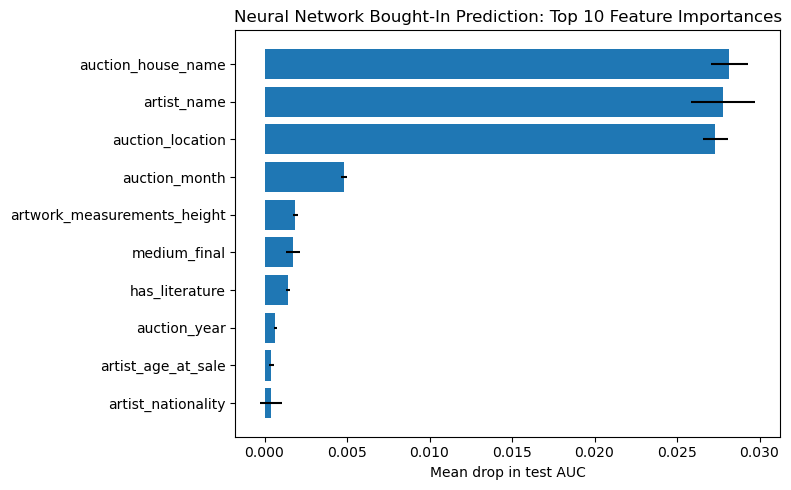

In [13]:
# baseline test AUC
baseline_test_prob = model.predict_proba(X_test)[:, 1]
baseline_test_auc = roc_auc_score(y_test, baseline_test_prob)

print("Baseline test AUC:", round(baseline_test_auc, 4))

# individual feature permutation importance
def permutation_importance_auc(
    model,
    X_test,
    y_test,
    feature_cols,
    n_repeats=5,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    results = []

    baseline_prob = model.predict_proba(X_test)[:, 1]
    baseline_auc = roc_auc_score(y_test, baseline_prob)

    for col in feature_cols:
        drops = []

        for _ in range(n_repeats):
            X_perm = X_test.copy()
            X_perm[col] = rng.permutation(X_perm[col].values)

            perm_prob = model.predict_proba(X_perm)[:, 1]
            perm_auc = roc_auc_score(y_test, perm_prob)

            drop = baseline_auc - perm_auc
            drops.append(drop)

        results.append({
            "feature": col,
            "importance_mean_auc_drop": np.mean(drops),
            "importance_std_auc_drop": np.std(drops),
        })

    results_df = pd.DataFrame(results).sort_values(
        "importance_mean_auc_drop", ascending=False
    ).reset_index(drop=True)

    return results_df


perm_importance_auc = permutation_importance_auc(
    model=model,
    X_test=X_test,
    y_test=y_test,
    feature_cols=feature_cols,
    n_repeats=5,
    random_state=42
)

print("\nTop individual features by permutation importance (AUC drop):")
print(perm_importance_auc.head(20))

perm_importance_auc.to_csv("nn_boughtin_feature_importance_auc.csv", index=False)

# plot: top 10 individual feature importances
top10_auc = perm_importance_auc.head(10).sort_values(
    "importance_mean_auc_drop", ascending=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    top10_auc["feature"],
    top10_auc["importance_mean_auc_drop"],
    xerr=top10_auc["importance_std_auc_drop"]
)
plt.xlabel("Mean drop in test AUC")
plt.ylabel("")
plt.title("Neural Network Bought-In Prediction: Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("nn_boughtin_top10_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# Results presentation

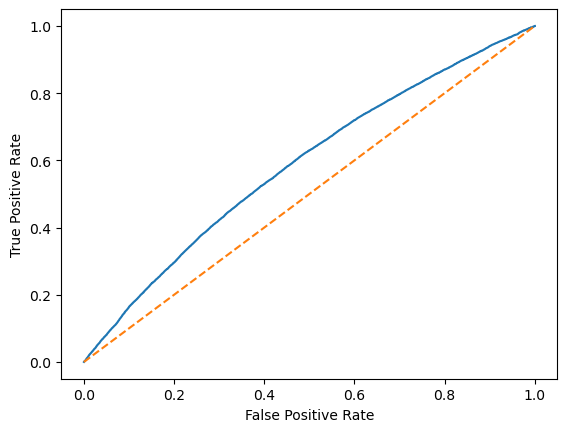

In [15]:
fpr, tpr, _ = roc_curve(y_test, test_pred_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig("nn_roc_curve.png", bbox_inches="tight")
plt.show()

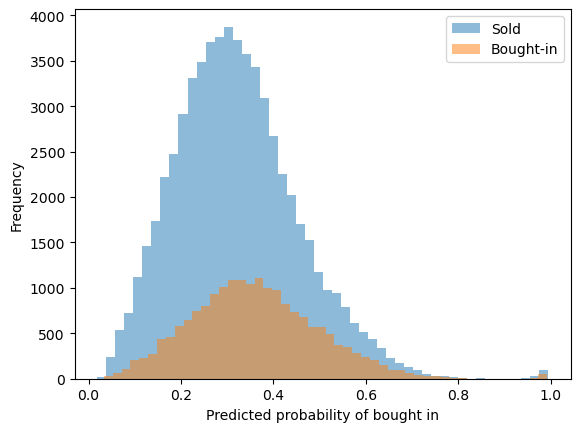

In [16]:
plt.figure()

plt.hist(test_pred_prob[y_test == 0], bins=50, alpha=0.5, label="Sold")
plt.hist(test_pred_prob[y_test == 1], bins=50, alpha=0.5, label="Bought-in")

plt.xlabel("Predicted probability of bought in")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("nn_prob_distribution.png", bbox_inches="tight")
plt.show()